In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("dataset_olympics.csv")
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  object 
 2   Sex     70000 non-null  object 
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  object 
 7   NOC     70000 non-null  object 
 8   Games   70000 non-null  object 
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  object 
 11  City    70000 non-null  object 
 12  Sport   70000 non-null  object 
 13  Event   70000 non-null  object 
 14  Medal   9690 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 8.0+ MB


In [10]:
data.describe()

,ID,Age,Height,Weight,Year
count,70000.000000,67268.000000,53746.000000,52899.000000,70000.000000
mean,18081.846986,25.644645,175.505303,70.900216,1977.766457
std,10235.613253,6.485239,10.384203,14.217489,30.103306
min,1.000000,11.000000,127.000000,25.000000,1896.000000
25%,9325.750000,21.000000,168.000000,61.000000,1960.000000
50%,18032.000000,25.000000,175.000000,70.000000,1984.000000
75%,26978.000000,28.000000,183.000000,79.000000,2002.000000
max,35658.000000,88.000000,223.000000,214.000000,2016.000000


In [11]:
data.describe(include=["object"])

,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
count,70000,70000,70000,70000,70000,70000,70000,70000,70000,9690
unique,35556,2,827,226,51,2,42,65,744,3
top,Oksana Aleksandrovna Chusovitina,M,United States,USA,2016 Summer,Summer,London,Athletics,Football Men's Football,Gold
freq,29,51877,4979,5216,3675,58467,6034,10629,1738,3292


In [13]:
data.isna().sum()

ID            0
Name          0
Sex           0
Age        2732
Height    16254
Weight    17101
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     60310
dtype: int64

In [15]:
data.duplicated().sum()

np.int64(383)

In [18]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

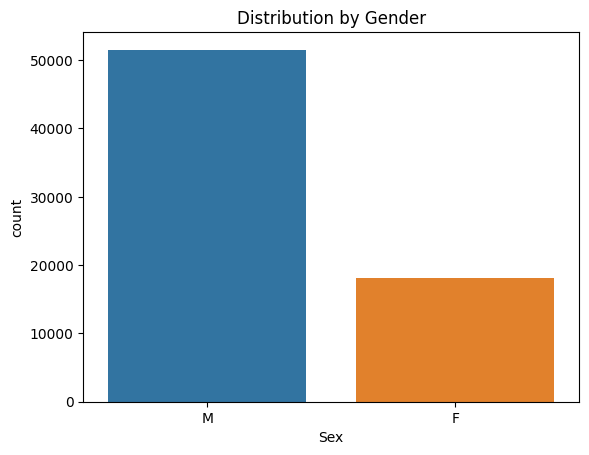

In [23]:
sns.countplot( data= data, x='Sex', hue="Sex")
plt.title('Distribution by Gender')
plt.show()


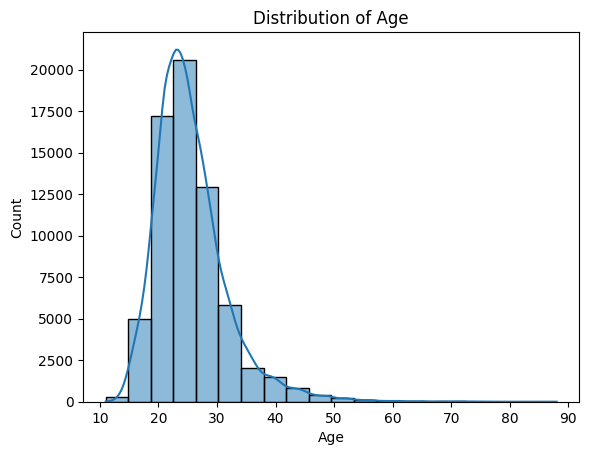

In [30]:
sns.histplot( data= data, x='Age', bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

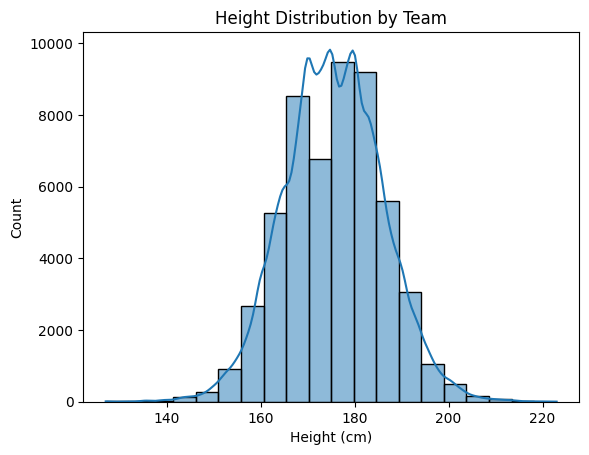

In [33]:
sns.histplot( data= data, x='Height',bins=20, kde=True)
plt.title('Height Distribution by Team')
plt.xlabel('Height (cm)')
plt.show()

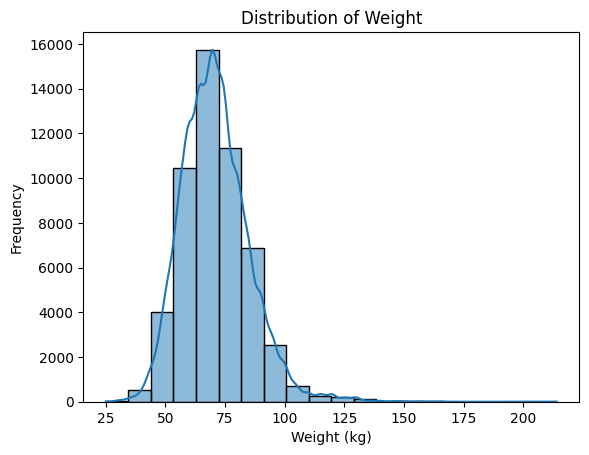

In [35]:
sns.histplot( data= data, x='Weight',bins=20, kde=True)
plt.title('Distribution of Weight')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.show()

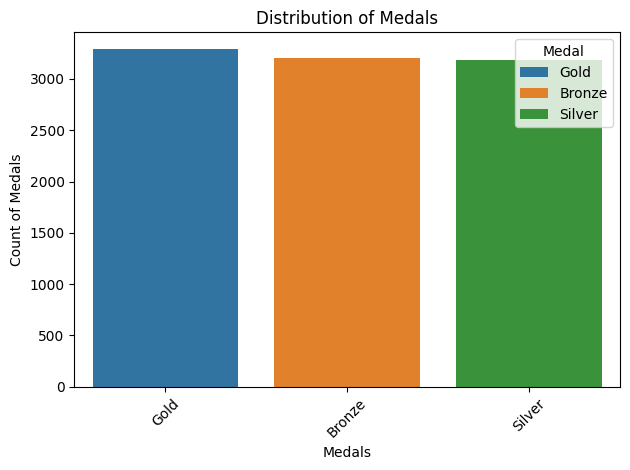

In [39]:
sns.countplot(data=data ,x='Medal', hue='Medal')
plt.title('Distribution of Medals')
plt.xlabel('Medals')
plt.ylabel('Count of Medals')
plt.xticks(rotation=45)
plt.tight_layout()

In [43]:
year_avg_age = data.groupby("Year")["Age"].mean()
year_avg_age.reset_index()

,Year,Age
0,1896,23.029412
1,1900,29.119883
2,1904,27.063241
3,1906,26.989474
4,1908,27.000000
5,1912,27.965552
6,1920,29.241135
7,1924,28.252267
8,1928,27.973564
9,1932,29.606987


In [45]:
sport_median_height = data.groupby("Sport")["Height"].median()
sport_median_height

Sport
Alpine Skiing       173.0
Alpinism              NaN
Archery             172.0
Art Competitions    183.0
Athletics           176.0
                    ...  
Tug-Of-War          182.0
Volleyball          187.5
Water Polo          185.0
Weightlifting       168.0
Wrestling           172.0
Name: Height, Length: 65, dtype: float64

In [48]:
country_gender_count = data.groupby(["NOC","Sex"])["ID"].count()
country_gender_count.reset_index()

,NOC,Sex,ID
0,AFG,M,38
1,AHO,F,6
2,AHO,M,27
3,ALB,F,4
4,ALB,M,7
...,...,...,...
427,YUG,M,455
428,ZAM,F,3
429,ZAM,M,40
430,ZIM,F,41


In [55]:
country_gold_medals = data[data["Medal"] == "Gold"].groupby("NOC")["Medal"].count().sort_values(ascending = False).head(10)
country_gold_medals

NOC
USA    747
ITA    217
URS    216
GBR    210
FRA    184
GER    148
CAN    119
NOR    104
AUS     98
HUN     94
Name: Medal, dtype: int64

In [61]:
sports_gender_avg_weight = data.groupby(["Sport", "Sex"])["Weight"].mean()
sports_gender_avg_weight

Sport          Sex
Alpine Skiing  F      62.154589
               M      77.725309
Alpinism       F            NaN
               M            NaN
Archery        F      61.023256
                        ...    
Water Polo     M      87.584973
Weightlifting  F      66.189474
               M      79.927852
Wrestling      F      58.169014
               M      77.256240
Name: Weight, Length: 114, dtype: float64

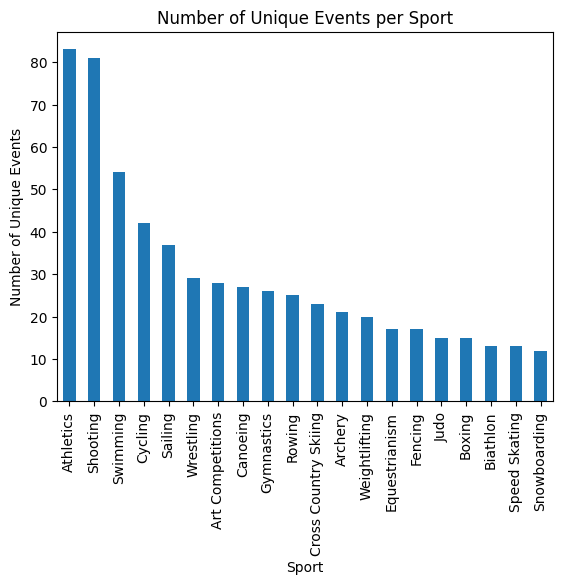

In [68]:
sport_event_count = data.groupby("Sport")["Event"].nunique().sort_values(ascending = False).head(20)
sport_event_count.plot( kind='bar', title='Number of Unique Events per Sport')
plt.xlabel("Sport")
plt.ylabel("Number of Unique Events")
plt.show()


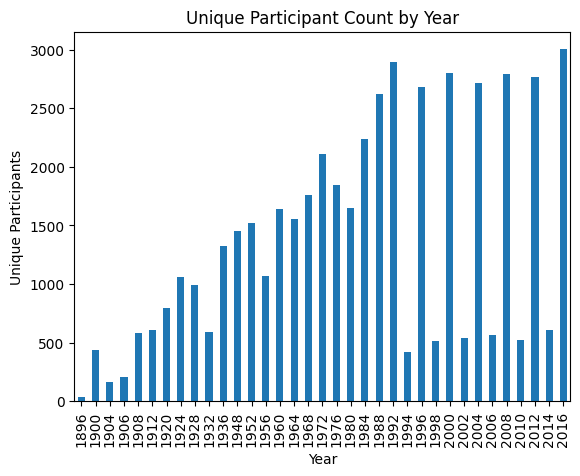

In [72]:
year_participant_count = data.groupby("Year")["ID"].nunique()
year_participant_count.plot(kind="bar", title="Unique Participant Count by Year")
plt.xlabel("Year")
plt.ylabel("Unique Participants")
plt.show()

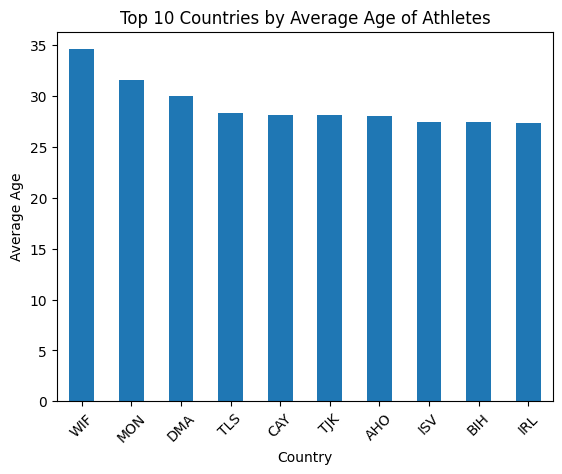

In [84]:
country_avg_age = data.groupby('NOC')['Age'].mean().sort_values(ascending = False).head(10)
country_avg_age.plot(kind = "bar")
plt.title("Top 10 Countries by Average Age of Athletes")
plt.xlabel("Country")
plt.ylabel("Average Age")
plt.xticks(rotation=45)
plt.show()

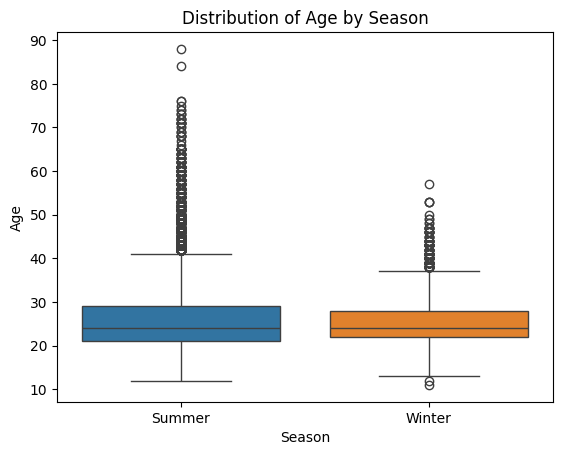

In [86]:
sns.boxplot( data=data, x='Season', y='Age', hue="Season")
plt.title('Distribution of Age by Season')
plt.xlabel('Season')
plt.ylabel('Age')
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_64476\2665091501.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot( data = data, x='Medal', y='Height', palette="Set2")


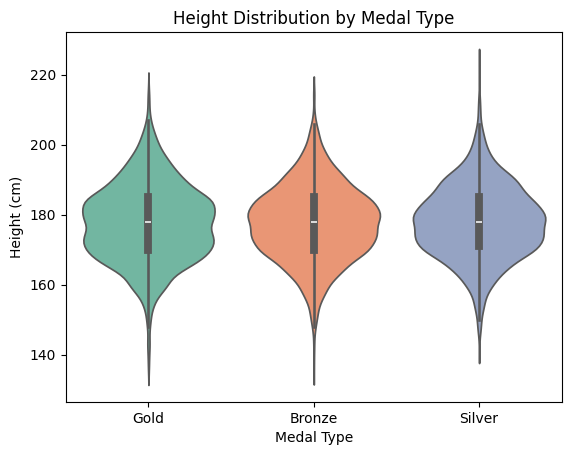

In [93]:
sns.violinplot( data = data, x='Medal', y='Height', palette="Set2")
plt.title('Height Distribution by Medal Type')
plt.xlabel('Medal Type')
plt.ylabel('Height (cm)')
plt.show()

In [107]:
country_with_most_medals = data.groupby('NOC')['Medal'].value_counts().idxmax()
print("Country with the most Medals: ", country_with_most_medals)

Country with the most Medals:  ('USA', 'Gold')


In [114]:
tallest_athelete = data[data["Height"] == data["Height"].max()]
tallest_athelete[["ID", "Name", "Height", "Sport", "NOC"]].reset_index()

,index,ID,Name,Height,Sport,NOC
0,32376,16639,Tommy Loren Burleson,223.0,Basketball,USA


In [120]:
heaviest_athelete = data[data["Weight"] == data["Weight"].max()].head(1)
heaviest_athelete[["ID", "Name", "Weight", "Sport", "NOC"]].reset_index()

,index,ID,Name,Weight,Sport,NOC
0,23155,12177,"Ricardo Blas, Jr.",214.0,Judo,GUM


<Axes: xlabel='Height', ylabel='Weight'>

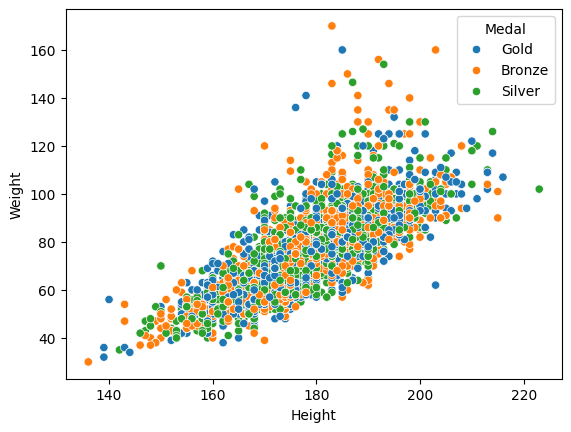

In [124]:
sns.scatterplot( x='Height', y='Weight', data=data, hue="Medal")

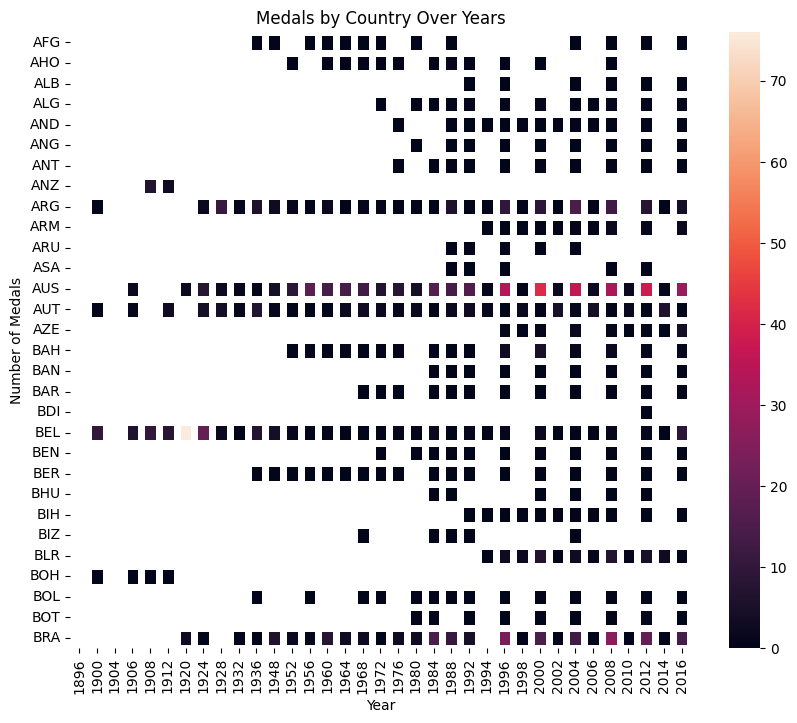

In [ ]:
medals_by_country_year = data.pivot_table(index = "NOC", columns = "Year", values= 'Medal', aggfunc="count").head(30)
plt.figure(figsize=(10,8))
sns.heatmap(medals_by_country_year, linewidths=5)
plt.title("Medals by Country Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.show()